In [19]:
# This script reads three populations (clustered, random, grid) of size N0
# and expands them to size N = k^2 while preserving spatial structure.
# - clustered & random: replicate points with small jitter
# - grid: rebuild a k x k grid

import pandas as pd
import numpy as np
from pathlib import Path
from package_sampling.utils import inclusion_probabilities


base_path = Path("/home/bardia/graphical-sampling/populations")

# --------------------------------
# PARAMETERS
# --------------------------------
TARGET_N = 144   # must have integer sqrt


# --------------------------------
# Helper: check perfect square
# --------------------------------
def sqrt_int(n):
    k = int(np.sqrt(n))
    if k * k != n:
        raise ValueError(f"N={n} must have an integer square root.")
    return k


# --------------------------------
# Helper: jitter replication
# --------------------------------
def expand_with_jitter(df, target_n, jitter_scale=0.01, seed=123):

    np.random.seed(seed)

    reps = target_n // len(df)
    remainder = target_n % len(df)

    dfs = []

    for r in range(reps):

        tmp = df.copy()

        if r > 0:
            tmp["x"] += np.random.normal(0, jitter_scale, size=len(tmp))
            tmp["y"] += np.random.normal(0, jitter_scale, size=len(tmp))

        dfs.append(tmp)

    if remainder > 0:

        tmp = df.sample(remainder, replace=False, random_state=seed).copy()

        tmp["x"] += np.random.normal(0, jitter_scale, size=len(tmp))
        tmp["y"] += np.random.normal(0, jitter_scale, size=len(tmp))

        dfs.append(tmp)

    out = pd.concat(dfs, ignore_index=True)

    return out.iloc[:target_n]


# --------------------------------
# Grid expansion
# --------------------------------
def expand_grid(df, target_n):

    k = sqrt_int(target_n)

    xmin, xmax = df["x"].min(), df["x"].max()
    ymin, ymax = df["y"].min(), df["y"].max()

    xs = np.linspace(xmin, xmax, k)
    ys = np.linspace(ymin, ymax, k)

    xx, yy = np.meshgrid(xs, ys)

    attr_cols = [c for c in df.columns if c not in ["x", "y"]]

    attrs = df[attr_cols].values

    reps = int(np.ceil(target_n / len(attrs)))

    attrs_big = np.tile(attrs, (reps, 1))[:target_n]

    grid_new = pd.DataFrame({
        "x": xx.flatten(),
        "y": yy.flatten(),
    })

    for i, col in enumerate(attr_cols):
        grid_new[col] = attrs_big[:, i]

    return grid_new


# --------------------------------
# Clustered population
# --------------------------------
clust = pd.read_csv(base_path / "clust.csv")

clust_new = expand_with_jitter(
    clust,
    target_n=TARGET_N,
    jitter_scale=0.015
)

clust_new.to_csv(base_path / f"clust_N{TARGET_N}.csv", index=False)


# --------------------------------
# Random population
# --------------------------------
rand = pd.read_csv(base_path / "rand.csv")

rand_new = expand_with_jitter(
    rand,
    target_n=TARGET_N,
    jitter_scale=0.02
)

rand_new.to_csv(base_path / f"rand_N{TARGET_N}.csv", index=False)


# --------------------------------
# Grid population
# --------------------------------
grid = pd.read_csv(base_path / "grid.csv")

grid_new = expand_grid(grid, TARGET_N)

grid_new.to_csv(base_path / f"grid_N{TARGET_N}.csv", index=False)


print(f"Expanded populations written for N={TARGET_N}:")
print(f" - clust_N{TARGET_N}.csv")
print(f" - rand_N{TARGET_N}.csv")
print(f" - grid_N{TARGET_N}.csv")


Expanded populations written for N=144:
 - clust_N144.csv
 - rand_N144.csv
 - grid_N144.csv


In [20]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------
base_path = Path("/home/bardia/graphical-sampling/populations")
fig_path  = base_path / "figures"
fig_path.mkdir(exist_ok=True)

# --------------------------------------------------
# Read populations
# --------------------------------------------------
grid_df  = pd.read_csv(base_path / f"grid_N{TARGET_N}.csv")
rand_df  = pd.read_csv(base_path / f"rand_N{TARGET_N}.csv")
clust_df = pd.read_csv(base_path / f"clust_N{TARGET_N}.csv")

# --------------------------------------------------
# Seeded permutation of inclusion probabilities
# --------------------------------------------------
seed = 2024
rng = np.random.default_rng(seed)

def permute_prob(df, col="prob", rng=None):
    df = df.copy()
    df[col] = rng.permutation(df[col].values)
    return df

grid_df_p  = permute_prob(grid_df,  rng=rng)
rand_df_p  = permute_prob(rand_df,  rng=rng)
clust_df_p = permute_prob(clust_df, rng=rng)

populations_perm = {
    "grid":  grid_df_p,
    "rand":  rand_df_p,
    "clust": clust_df_p
}


In [21]:
grid_df_p.to_csv(base_path / f"grid_N{TARGET_N}_perm.csv", index=False)
rand_df_p.to_csv(base_path / f"rand_N{TARGET_N}_perm.csv", index=False)
clust_df_p.to_csv(base_path / f"clust_N{TARGET_N}_perm.csv", index=False)


In [22]:
import matplotlib.pyplot as plt
import numpy as np

def global_limits(populations, pad=0.03):
    xs = np.concatenate([df["x"].values for df in populations.values()])
    ys = np.concatenate([df["y"].values for df in populations.values()])

    dx = xs.max() - xs.min()
    dy = ys.max() - ys.min()

    return (
        (xs.min() - pad * dx, xs.max() + pad * dx),
        (ys.min() - pad * dy, ys.max() + pad * dy)
    )

def plot_2x3(populations, size_var="prob", size_scale=400,
             figsize=(7.2, 4.8), save_path=None,
             common_limits=True):

    titles = ["Gridded", "Random", "Clustered"]
    keys   = ["grid", "rand", "clust"]

    if common_limits:
        xlim, ylim = global_limits(populations)

    fig, axes = plt.subplots(2, 3, figsize=figsize, dpi=300, gridspec_kw={"wspace":0, "hspace":0})

    for j, key in enumerate(keys):
        df = populations[key]

        # ---------- EP ----------
        ax = axes[0, j]
        ax.scatter(df["x"], df["y"],
                   s=10, alpha=0.75, color='.3',
                   edgecolor="black", linewidth=0.3)
        ax.set_title(titles[j], fontsize=10, fontweight='bold')

        # ---------- UP ----------
        ax2 = axes[1, j]
        pik = inclusion_probabilities(df[size_var], 10)
        sizes = size_scale * pik / pik.max()
        ax2.scatter(df["x"], df["y"],
                    s=sizes, alpha=0.75, color='.3',
                    edgecolor="black", linewidth=0.3)

        if j == 0:
            ax.set_ylabel("EP", fontsize=10, fontweight='bold')
            ax2.set_ylabel("UP", fontsize=10, fontweight='bold')

        # enforce limits
        if common_limits:
            ax.set_xlim(xlim);  ax.set_ylim(ylim)
            ax2.set_xlim(xlim); ax2.set_ylim(ylim)

    for ax in axes.flat:
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout(pad=0.6)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


In [23]:
populations = {
    "grid": grid_df,
    "rand": rand_df,
    "clust": clust_df
}

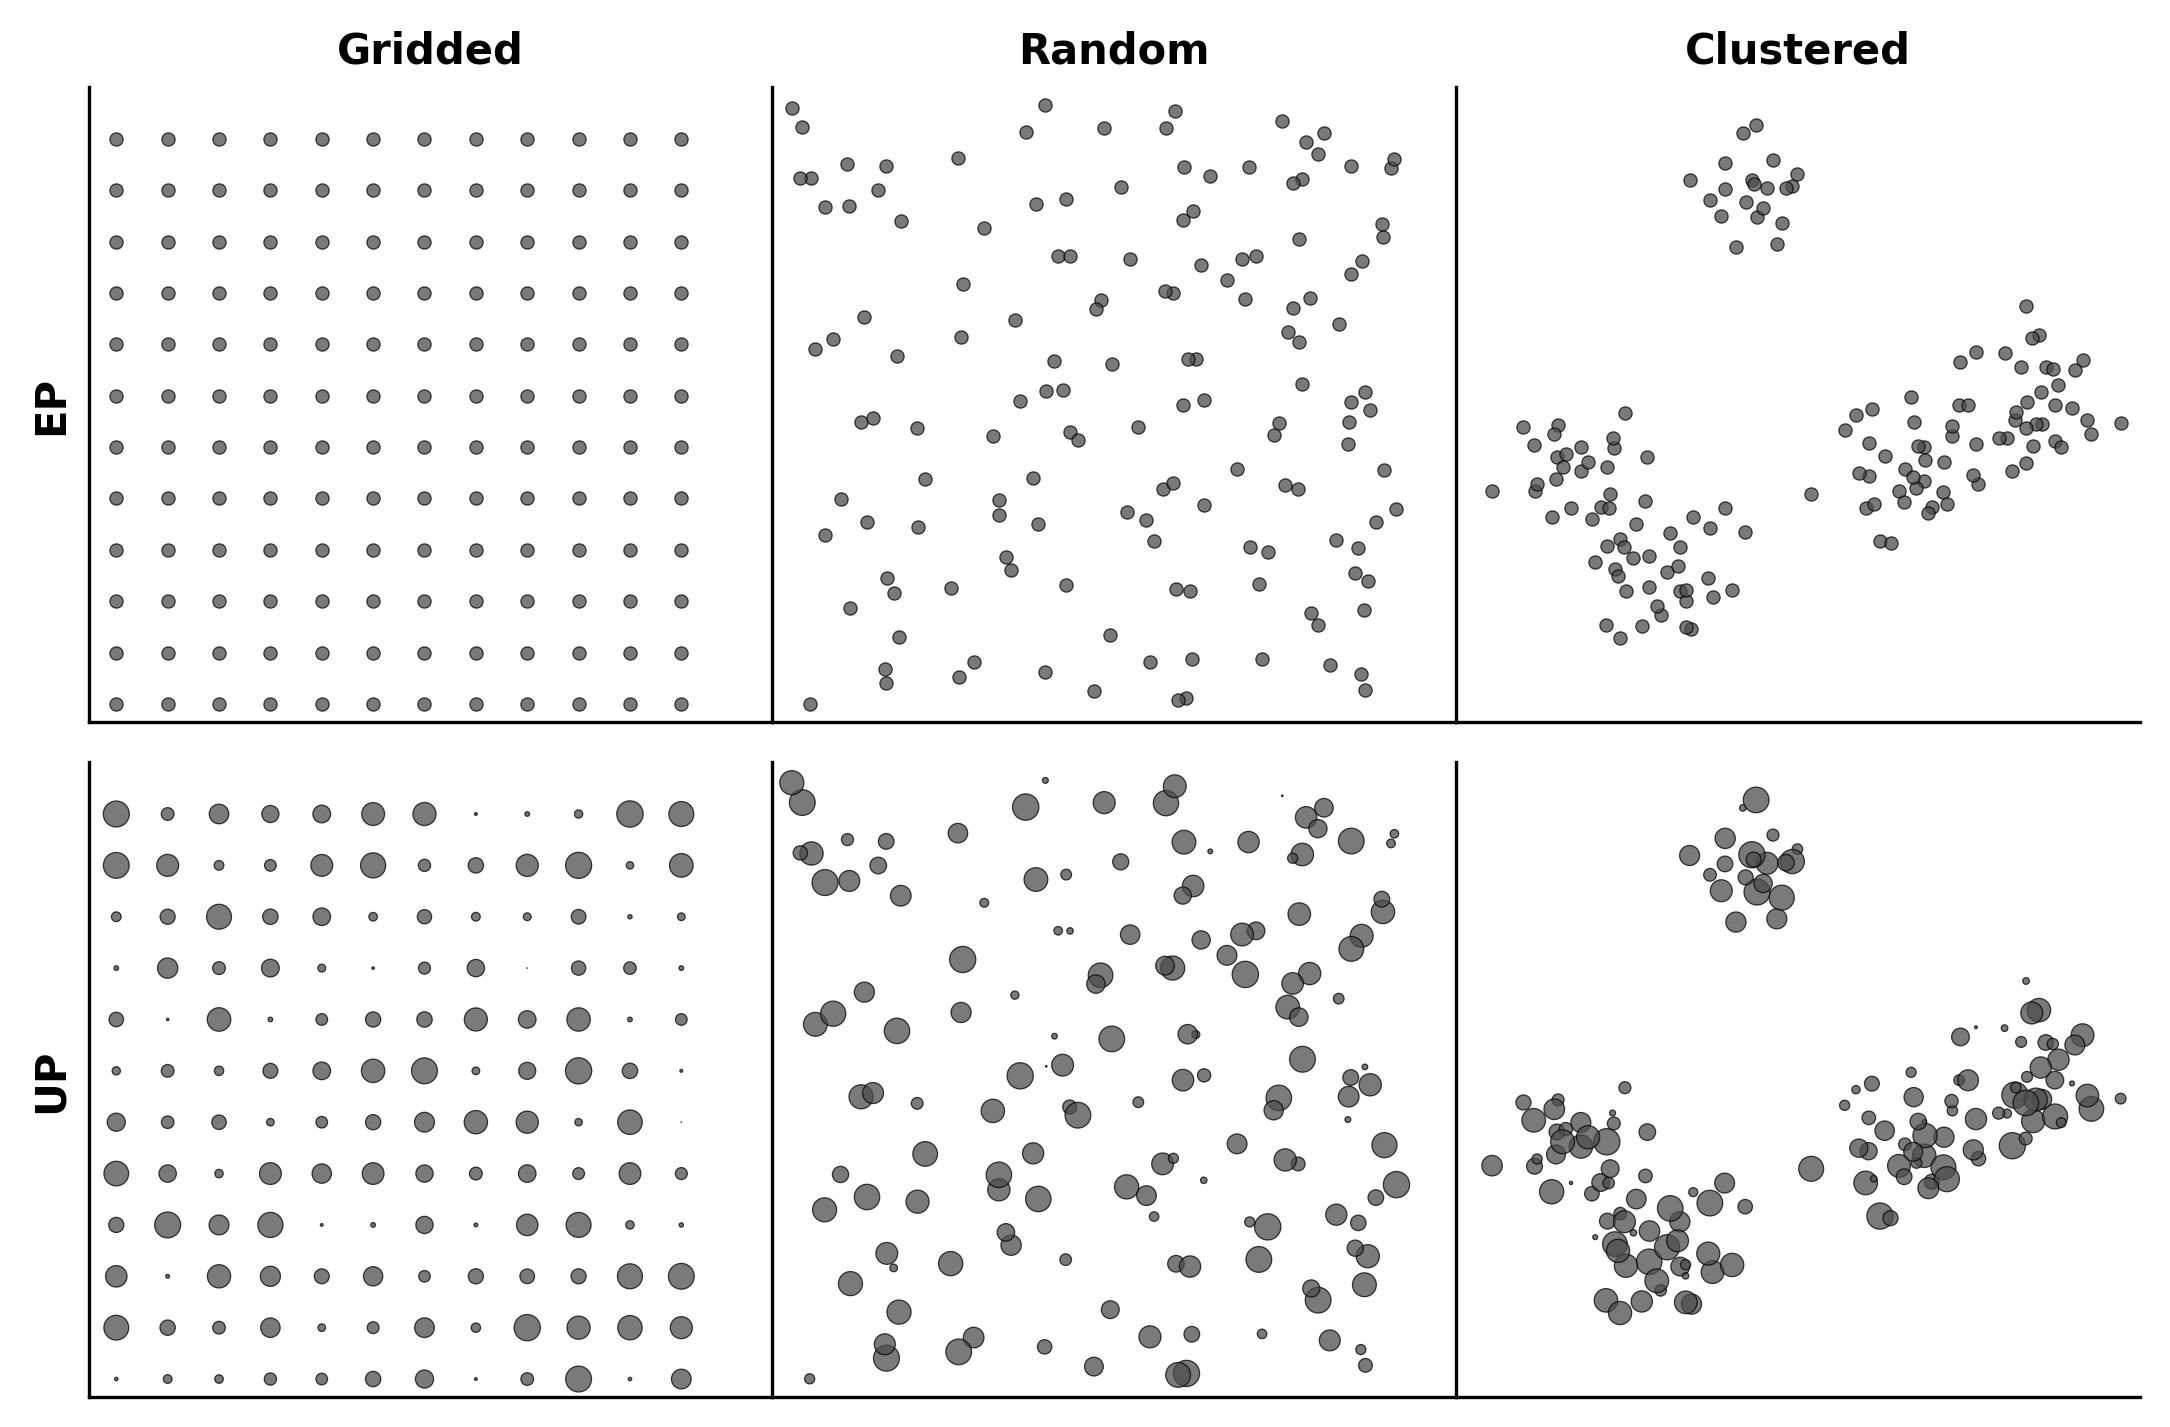

In [24]:
plot_2x3(
    populations_perm,
    size_var="prob",
    size_scale=40,
    figsize=(7.2, 4.8),
    save_path=fig_path / "Fig_three_popu_perm.pdf"
)
